In [48]:
# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Bibliotecas especializadas
import missingno as msno
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
import category_encoders as ce
import math
import seaborn as sns
import matplotlib.pyplot as plt

print(" Bibliotecas importadas!")

 Bibliotecas importadas!


Carregamento e Exploração de Dados

In [49]:
from pathlib import Path
import pandas as pd
import os

# Caminho da pasta onde estão os CSVs
path = Path('/home/luma/4 PERÍODO/APRENDIZAGEM DE MÁQUINA/Projeto-aprendizagem-de-maquina-/data/Airbnb Prices in European Cities/raw')

list_of_dfs = []

for file in os.listdir(path):
    if file.endswith(".csv"):
        
        file_path = path / file
        print(f"📂 Lendo arquivo: {file_path}")

        # Lê o CSV
        df_temp = pd.read_csv(file_path)

        # Adiciona coluna indicando de qual arquivo veio
        df_temp["source_file"] = file.replace(".csv", "")

        list_of_dfs.append(df_temp)

        print(f"✔ Lido: {file} | Linhas: {len(df_temp)}")

# Junta tudo em um único DataFrame
df = pd.concat(list_of_dfs, ignore_index=True)

print("\n--------------------------------------------")
print("📊 Todos os dados foram combinados em `df`")
print(f"Total de linhas: {len(df)}")
print(f"Colunas: {df.columns.tolist()}")


📂 Lendo arquivo: /home/luma/4 PERÍODO/APRENDIZAGEM DE MÁQUINA/Projeto-aprendizagem-de-maquina-/data/Airbnb Prices in European Cities/raw/berlin_weekdays.csv
✔ Lido: berlin_weekdays.csv | Linhas: 1284
📂 Lendo arquivo: /home/luma/4 PERÍODO/APRENDIZAGEM DE MÁQUINA/Projeto-aprendizagem-de-maquina-/data/Airbnb Prices in European Cities/raw/london_weekends.csv
✔ Lido: london_weekends.csv | Linhas: 5379
📂 Lendo arquivo: /home/luma/4 PERÍODO/APRENDIZAGEM DE MÁQUINA/Projeto-aprendizagem-de-maquina-/data/Airbnb Prices in European Cities/raw/london_weekdays.csv
✔ Lido: london_weekdays.csv | Linhas: 4614
📂 Lendo arquivo: /home/luma/4 PERÍODO/APRENDIZAGEM DE MÁQUINA/Projeto-aprendizagem-de-maquina-/data/Airbnb Prices in European Cities/raw/paris_weekends.csv
✔ Lido: paris_weekends.csv | Linhas: 3558
📂 Lendo arquivo: /home/luma/4 PERÍODO/APRENDIZAGEM DE MÁQUINA/Projeto-aprendizagem-de-maquina-/data/Airbnb Prices in European Cities/raw/budapest_weekdays.csv
✔ Lido: budapest_weekdays.csv | Linhas: 207

Análise Exploratória Estrutural

In [50]:
# 1. Informações básicas do dataset
print("\n1️⃣ INFORMAÇÕES GERAIS:")
print(f"Shape: {df.shape}")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


1️⃣ INFORMAÇÕES GERAIS:
Shape: (51707, 21)
Memória: 13.50 MB


In [51]:
# 2. Tipos de dados
print("\n2️⃣ TIPOS DE DADOS:")
print(df.dtypes)


2️⃣ TIPOS DE DADOS:
Unnamed: 0                      int64
realSum                       float64
room_type                      object
room_shared                      bool
room_private                     bool
person_capacity               float64
host_is_superhost                bool
multi                           int64
biz                             int64
cleanliness_rating            float64
guest_satisfaction_overall    float64
bedrooms                        int64
dist                          float64
metro_dist                    float64
attr_index                    float64
attr_index_norm               float64
rest_index                    float64
rest_index_norm               float64
lng                           float64
lat                           float64
source_file                    object
dtype: object


In [52]:
# 3. Primeiras linhas
print("\n3️⃣ PRIMEIRAS 5 LINHAS:")
display(df.head())


3️⃣ PRIMEIRAS 5 LINHAS:


,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,source_file
0,0,185.799757,Private room,False,True,2.0,True,0,0,10.0,98.0,1,3.582211,0.174706,105.063708,16.019042,148.941114,30.710638,13.42344,52.49150,berlin_weekdays
1,1,194.914462,Private room,False,True,5.0,False,0,1,9.0,86.0,1,3.525410,0.511922,75.339529,11.487002,106.442356,21.947685,13.46800,52.51900,berlin_weekdays
2,2,176.217631,Private room,False,True,2.0,False,0,0,9.0,91.0,1,3.801713,0.281397,73.669176,11.232324,105.440205,21.741048,13.47096,52.51527,berlin_weekdays
3,3,207.768533,Private room,False,True,3.0,True,0,0,10.0,97.0,1,0.982408,0.705573,133.187409,20.307057,198.233362,40.874362,13.42281,52.53139,berlin_weekdays
4,4,150.743199,Private room,False,True,2.0,False,0,0,10.0,99.0,1,8.869697,2.187188,39.860151,6.077469,50.996308,10.515090,13.52440,52.47842,berlin_weekdays


In [53]:
# 4. Informações detalhadas
print("\n4️⃣ INFO DETALHADA:")
df.info()


4️⃣ INFO DETALHADA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51707 entries, 0 to 51706
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  51707 non-null  int64  
 1   realSum                     51707 non-null  float64
 2   room_type                   51707 non-null  object 
 3   room_shared                 51707 non-null  bool   
 4   room_private                51707 non-null  bool   
 5   person_capacity             51707 non-null  float64
 6   host_is_superhost           51707 non-null  bool   
 7   multi                       51707 non-null  int64  
 8   biz                         51707 non-null  int64  
 9   cleanliness_rating          51707 non-null  float64
 10  guest_satisfaction_overall  51707 non-null  float64
 11  bedrooms                    51707 non-null  int64  
 12  dist                        51707 non-null  float64
 13  metro_dist

In [54]:
# 5. Estatísticas descritivas
print("\n5️⃣ ESTATÍSTICAS DESCRITIVAS:")
display(df.describe())


5️⃣ ESTATÍSTICAS DESCRITIVAS:


,Unnamed: 0,realSum,person_capacity,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
count,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.00000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000
mean,1620.502388,279.879591,3.161661,0.291353,0.350204,9.390624,92.628232,1.15876,3.191285,0.681540,294.204105,13.423792,626.856696,22.786177,7.426068,45.671128
std,1217.380366,327.948386,1.298545,0.454390,0.477038,0.954868,8.945531,0.62741,2.393803,0.858023,224.754123,9.807985,497.920226,17.804096,9.799725,5.249263
min,0.000000,34.779339,2.000000,0.000000,0.000000,2.000000,20.000000,0.00000,0.015045,0.002301,15.152201,0.926301,19.576924,0.592757,-9.226340,37.953000
25%,646.000000,148.752174,2.000000,0.000000,0.000000,9.000000,90.000000,1.00000,1.453142,0.248480,136.797385,6.380926,250.854114,8.751480,-0.072500,41.399510
50%,1334.000000,211.343089,3.000000,0.000000,0.000000,10.000000,95.000000,1.00000,2.613538,0.413269,234.331748,11.468305,522.052783,17.542238,4.873000,47.506690
75%,2382.000000,319.694287,4.000000,1.000000,1.000000,10.000000,99.000000,1.00000,4.263077,0.737840,385.756381,17.415082,832.628988,32.964603,13.518825,51.471885
max,5378.000000,18545.450285,6.000000,1.000000,1.000000,10.000000,100.000000,10.00000,25.284557,14.273577,4513.563486,100.000000,6696.156772,100.000000,23.786020,52.641410


In [55]:
# 6. Análise de valores únicos
print("\n6️⃣ VALORES ÚNICOS POR COLUNA:")
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} valores únicos")


6️⃣ VALORES ÚNICOS POR COLUNA:
Unnamed: 0: 5379 valores únicos
realSum: 10497 valores únicos
room_type: 3 valores únicos
room_shared: 2 valores únicos
room_private: 2 valores únicos
person_capacity: 5 valores únicos
host_is_superhost: 2 valores únicos
multi: 2 valores únicos
biz: 2 valores únicos
cleanliness_rating: 9 valores únicos
guest_satisfaction_overall: 53 valores únicos
bedrooms: 10 valores únicos
dist: 51707 valores únicos
metro_dist: 51707 valores únicos
attr_index: 51707 valores únicos
attr_index_norm: 51688 valores únicos
rest_index: 51707 valores únicos
rest_index_norm: 51688 valores únicos
lng: 23600 valores únicos
lat: 21484 valores únicos
source_file: 20 valores únicos


Análise de Missing Values

In [56]:
# 1. Contagem de missing values
print("\n1️⃣ MISSING VALUES POR COLUNA:")
missing_data = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)
print(missing_data)


1️⃣ MISSING VALUES POR COLUNA:
Empty DataFrame
Columns: [Coluna, Missing_Count, Missing_Percent]
Index: []


Análise Exploratória Univariada

In [57]:
# Separar variáveis por tipo
numeric_vars = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()

In [58]:
print(f"Variáveis numéricas: {numeric_vars}")
print(f"Variáveis categóricas: {categorical_vars}")

Variáveis numéricas: ['Unnamed: 0', 'realSum', 'person_capacity', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index', 'attr_index_norm', 'rest_index', 'rest_index_norm', 'lng', 'lat']
Variáveis categóricas: ['room_type', 'source_file']


In [59]:
# 1. ANÁLISE DE VARIÁVEIS NUMÉRICAS
print("\n1️⃣ ANÁLISE DE VARIÁVEIS NUMÉRICAS:")


1️⃣ ANÁLISE DE VARIÁVEIS NUMÉRICAS:


In [60]:
# Estatísticas descritivas detalhadas
for var in numeric_vars:
    if var in df.columns:
        print(f"\n📊 {var.upper()}:")
        data = df[var].dropna()

        # Estatísticas básicas
        print(f"  Mean: {data.mean():.2f}")
        print(f"  Median: {data.median():.2f}")
        print(f"  Std: {data.std():.2f}")
        print(f"  Skewness: {stats.skew(data):.2f}")
        print(f"  Kurtosis: {stats.kurtosis(data):.2f}")

        # Outliers (IQR method)
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")


📊 UNNAMED: 0:
  Mean: 1620.50
  Median: 1334.00
  Std: 1217.38
  Skewness: 0.83
  Kurtosis: -0.07
  Outliers: 392 (0.8%)

📊 REALSUM:
  Mean: 279.88
  Median: 211.34
  Std: 327.95
  Skewness: 21.42
  Kurtosis: 831.28


  Outliers: 3662 (7.1%)

📊 PERSON_CAPACITY:
  Mean: 3.16
  Median: 3.00
  Std: 1.30
  Skewness: 0.76
  Kurtosis: -0.54
  Outliers: 0 (0.0%)

📊 MULTI:
  Mean: 0.29
  Median: 0.00
  Std: 0.45
  Skewness: 0.92
  Kurtosis: -1.16
  Outliers: 0 (0.0%)

📊 BIZ:
  Mean: 0.35
  Median: 0.00
  Std: 0.48
  Skewness: 0.63
  Kurtosis: -1.61
  Outliers: 0 (0.0%)

📊 CLEANLINESS_RATING:
  Mean: 9.39
  Median: 10.00
  Std: 0.95
  Skewness: -2.85
  Kurtosis: 13.61
  Outliers: 1830 (3.5%)

📊 GUEST_SATISFACTION_OVERALL:
  Mean: 92.63
  Median: 95.00
  Std: 8.95
  Skewness: -3.17
  Kurtosis: 17.02
  Outliers: 2102 (4.1%)

📊 BEDROOMS:
  Mean: 1.16
  Median: 1.00
  Std: 0.63
  Skewness: 1.37
  Kurtosis: 8.69
  Outliers: 15374 (29.7%)

📊 DIST:
  Mean: 3.19
  Median: 2.61
  Std: 2.39
  Skewness: 1.73
  Kurtosis: 4.97
  Outliers: 1746 (3.4%)

📊 METRO_DIST:
  Mean: 0.68
  Median: 0.41
  Std: 0.86
  Skewness: 4.06
  Kurtosis: 23.70
  Outliers: 5051 (9.8%)

📊 ATTR_INDEX:
  Mean: 294.20
  Median: 234.33
  Std: 224.7

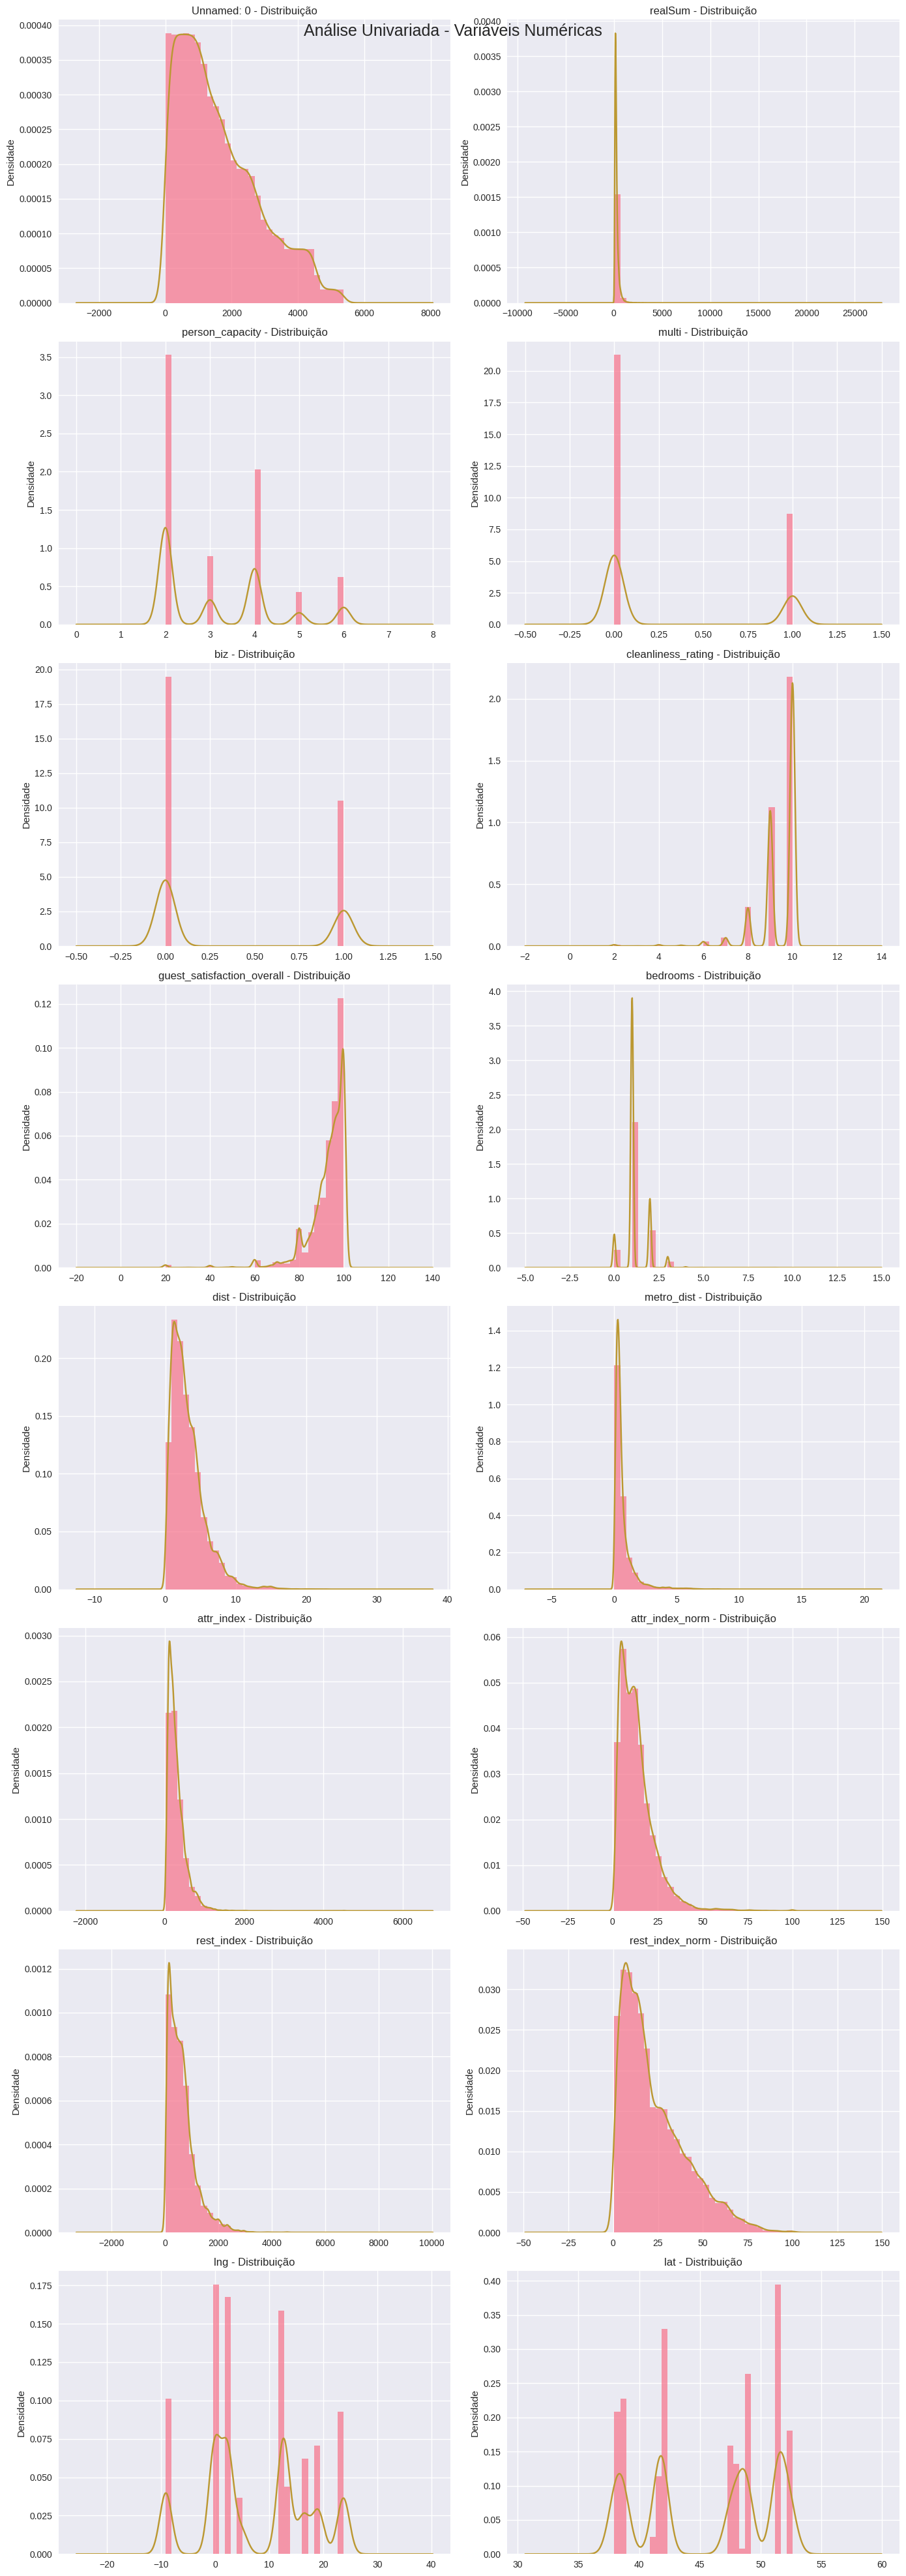

In [61]:
import math

# Total das variáveis numéricas
vars_to_plot = numeric_vars[:16]   # ou liste manualmente se preferir

cols = 2
rows = math.ceil(len(vars_to_plot) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
fig.suptitle('Análise Univariada - Variáveis Numéricas', fontsize=18)

axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]

    if var in df.columns:
        # Histograma
        ax.hist(df[var].dropna(), bins=30, alpha=0.7, density=True)

        # Linha de densidade (KDE)
        df[var].dropna().plot.density(ax=ax)

        ax.set_title(f'{var} - Distribuição')
        ax.set_ylabel('Densidade')

# Subplots vazios (caso existam)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


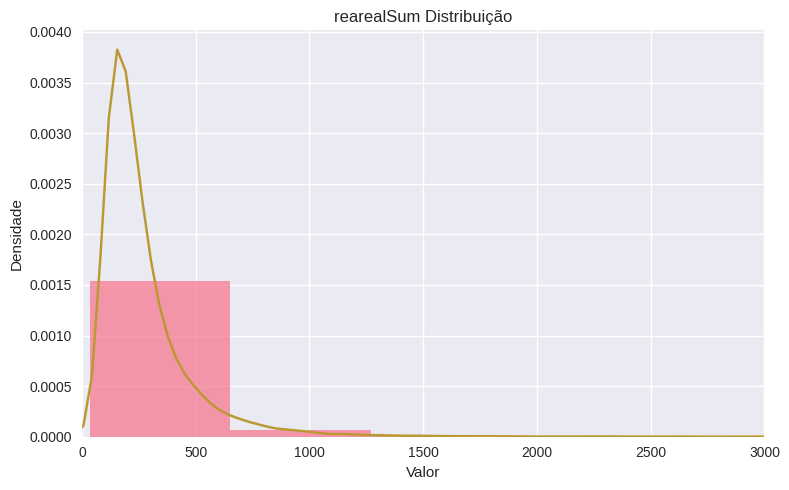

In [65]:
plt.figure(figsize=(8, 5))

plt.hist(df["realSum"].dropna(), bins=30, alpha=0.7, density=True)
df["realSum"].dropna().plot.density()

plt.title("rearealSum Distribuição")
plt.xlabel("Valor")
plt.ylabel("Densidade")

plt.xlim(0, 3000)   # escolha o valor ideal após observar o dataset

plt.tight_layout()
plt.show()


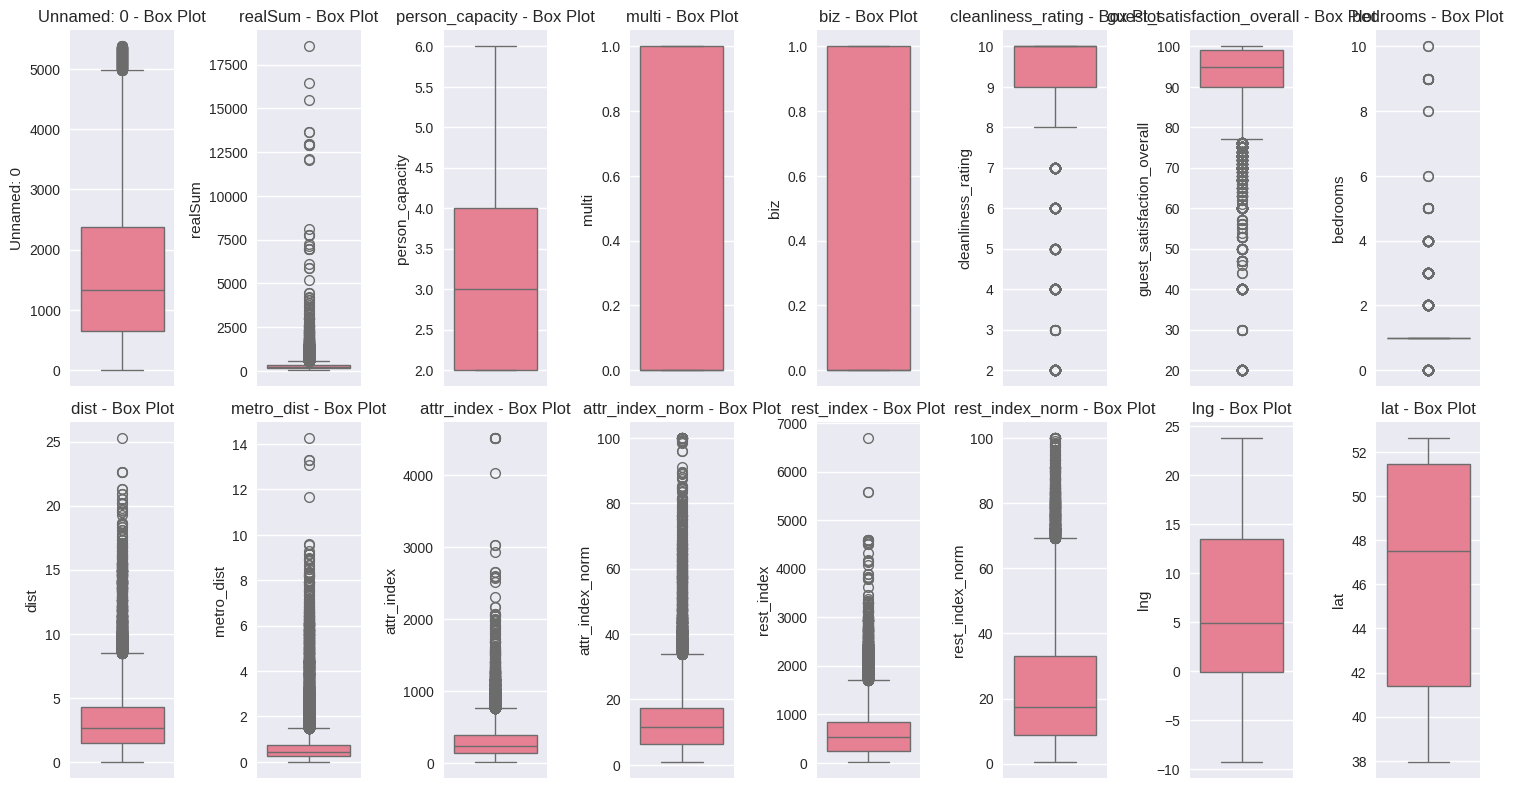

In [ ]:
# Box plots para identificar outliers
plt.figure(figsize=(15, 8))
numeric_data = df[numeric_vars].select_dtypes(include=[np.number])
# Select only the first 6 numeric variables to plot
variables_to_plot = numeric_data.columns[:16]
for i, var in enumerate(variables_to_plot):
    plt.subplot(2, 8, i+1)
    sns.boxplot(y=df[var])
    plt.title(f'{var} - Box Plot')
plt.tight_layout()
plt.show()

In [ ]:
# 2. ANÁLISE DE VARIÁVEIS CATEGÓRICAS
print("\n2️⃣ ANÁLISE DE VARIÁVEIS CATEGÓRICAS:")


2️⃣ ANÁLISE DE VARIÁVEIS CATEGÓRICAS:


In [ ]:
# Análise de frequências
for var in categorical_vars:
    if var in df.columns:
        print(f"\n📊 {var.upper()}:")
        freq_table = df[var].value_counts()
        freq_percent = df[var].value_counts(normalize=True) * 100

        freq_df = pd.DataFrame({
            'Frequência': freq_table,
            'Percentual': freq_percent
        })
        print(freq_df.head(10))

        # Medida de concentração (Índice de Herfindahl)
        herfindahl = (freq_percent/100).pow(2).sum()
        print(f"  Índice de Herfindahl: {herfindahl:.3f}")
        print(f"  Entropia: {stats.entropy(freq_table):.3f}")


📊 ROOM_TYPE:
                 Frequência  Percentual
room_type                              
Entire home/apt       32648   63.140387
Private room          18693   36.151778
Shared room             366    0.707835
  Índice de Herfindahl: 0.529
  Entropia: 0.693

📊 SOURCE_FILE:
                 Frequência  Percentual
source_file                            
london_weekends        5379   10.402847
london_weekdays        4614    8.923357
rome_weekends          4535    8.770573
rome_weekdays          4492    8.687412
paris_weekends         3558    6.881080
paris_weekdays         3130    6.053339
lisbon_weekends        2906    5.620129
lisbon_weekdays        2857    5.525364
athens_weekdays        2653    5.130833
athens_weekends        2627    5.080550
  Índice de Herfindahl: 0.063
  Entropia: 2.873


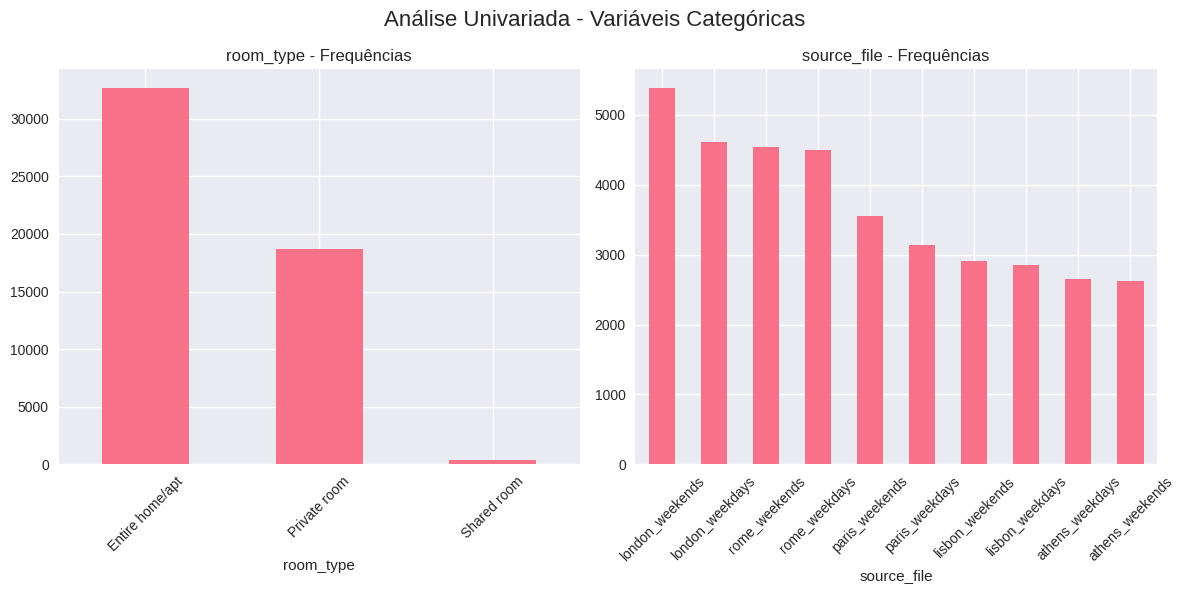

In [ ]:
# Visualizações das variáveis categóricas
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Análise Univariada - Variáveis Categóricas', fontsize=16)
for i, var in enumerate(categorical_vars[:2]):
    if var in df.columns:

        # Contagem de valores
        value_counts = df[var].value_counts().head(10)

        if len(value_counts) <= 10:  # Bar plot para poucas categorias
            value_counts.plot(kind='bar', ax=axes[i])
        else:  # Horizontal bar plot para muitas categorias
            value_counts.plot(kind='barh', ax=axes[i])

        axes[i].set_title(f'{var} - Frequências')
        axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

ANÁLISE EXPLORATÓRIA BIVARIADA

In [ ]:
# 1. CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS
print("\n1️⃣ MATRIZ DE CORRELAÇÃO:")


1️⃣ MATRIZ DE CORRELAÇÃO:


In [ ]:
# Calcular matriz de correlação
correlation_matrix = df[numeric_vars].corr()

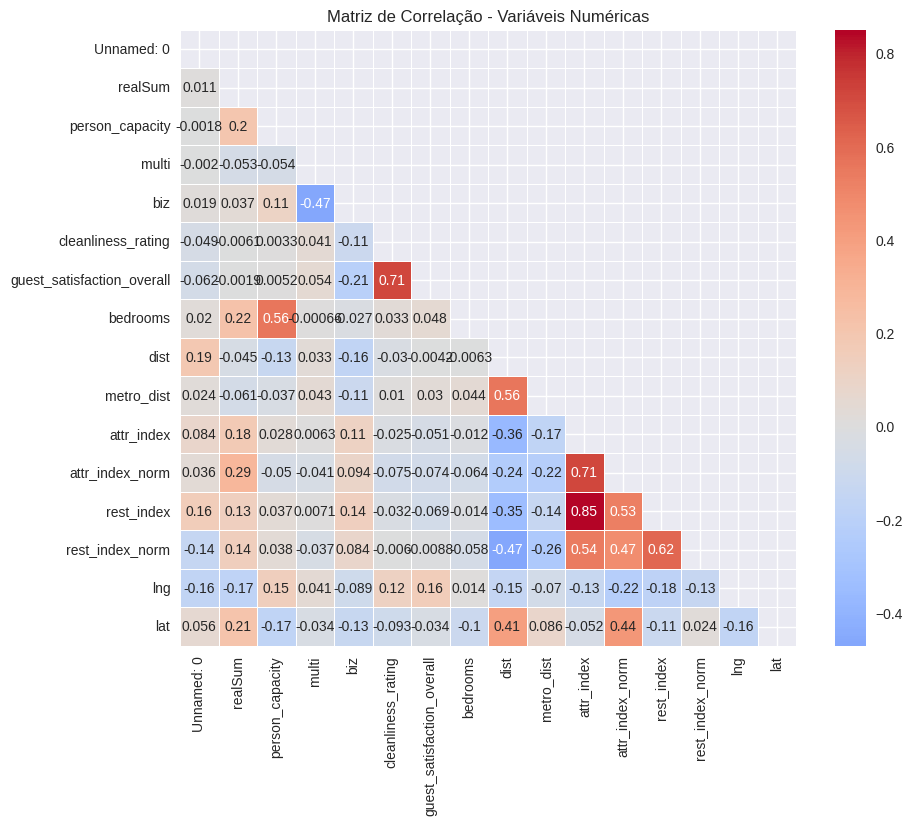

In [ ]:
# Visualizar heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.show()

In [ ]:
# Identificar correlações fortes
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:  # Correlação forte
            strong_corr.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': corr_val
            })

In [ ]:
if strong_corr:
    print("\n🔥 CORRELAÇÕES FORTES (|r| > 0.5):")
    for corr in strong_corr:
        print(f"  {corr['var1']} ↔ {corr['var2']}: {corr['correlation']:.3f}")


🔥 CORRELAÇÕES FORTES (|r| > 0.5):
  person_capacity ↔ bedrooms: 0.561
  cleanliness_rating ↔ guest_satisfaction_overall: 0.714
  dist ↔ metro_dist: 0.558
  attr_index ↔ attr_index_norm: 0.715
  attr_index ↔ rest_index: 0.850
  attr_index ↔ rest_index_norm: 0.544
  attr_index_norm ↔ rest_index: 0.528
  rest_index ↔ rest_index_norm: 0.618


In [ ]:
# 2. ANÁLISE TARGET vs VARIÁVEIS NUMÉRICAS
print("\n2️⃣ TARGET vs VARIÁVEIS NUMÉRICAS:")


2️⃣ TARGET vs VARIÁVEIS NUMÉRICAS:


In [ ]:
target_var = 'realSum'

In [ ]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()

corr = df[num_cols].corr()['realSum'].abs().sort_values(ascending=False)

top3 = corr.index[1:4].tolist()  # Ignora o próprio realSum
print("Top 3 variáveis mais correlacionadas:", top3)


Top 3 variáveis mais correlacionadas: ['attr_index_norm', 'bedrooms', 'lat']
